# 2. Where the correlation comes from — why `ρ` is what it is

Notebook 01 established *how much* variance symmetrization removes. This one asks **why**, because
that is what tells us where symmetrization will and won't pay off.

**The framing.** Symmetrization `P` is an **orthogonal projector** onto the symmetry-invariant
subspace. It deletes the symmetry-**breaking** part of the MC noise entirely and leaves the
symmetry-**preserving** part untouched. So

$$\rho \;=\; \text{the fraction of noise variance already living in the symmetric subspace},$$

and `r = m/[1+(m−1)ρ]` carries **two ceilings**:

| ceiling | reached when | meaning |
|---|---|---|
| `r ≤ m` | `ρ = 0` | finite orbit size — you only average `m` things |
| `r ≤ 1/ρ` | `m → ∞` | correlation floor — symmetric noise is untouchable |

roughly `r ≈ min(m, 1/ρ)`. **Which ceiling binds tells you what to do:** a `ρ`-limited system gains
nothing from a bigger group or cluster, while an `m`-limited system gains almost directly.

*(Note the ceiling is `m`, not `√m` — symmetrization divides **variance** by `m` and the **error bar**
by `√m`. `R` is a variance ratio.)*

In [1]:
import sys
sys.path.insert(0, '.')
import numpy as np
import matplotlib.pyplot as plt
from symm_variance_lib import Run
import noise_diagnostics as nd

plt.rcParams['figure.dpi'] = 110
sq = Run('../runs/square_16rank.hdf5')
fe = Run('../runs/fe_as_16rank.hdf5')

# blocks worth contrasting: (run, b0, b1, band-class, label)
# Band-permuting ops map band-diagonal entries to band-diagonal ones and off-diagonal to
# off-diagonal, so every orbit is cleanly 'intra' or 'inter' -- we can report mate-rho per class.
BLOCKS = [(sq, 0, 0, 'intra', 'square/D4  band-diag'),
          (fe, 0, 0, 'intra', 'FeAs  intraband'),
          (fe, 0, 1, 'inter', 'FeAs  INTERBAND')]

def mate_rho_by_class(run):
    """Mean symmetry-mate rho, split by whether the orbit lives in band-diagonal or
    band-off-diagonal entries."""
    out = {}
    for o in run.orbits():
        if o['forced_null'] or len(o['members']) < 2:
            continue
        cls = {'intra' if run.labels[x][0] == run.labels[x][1] else 'inter' for x in o['members']}
        if len(cls) != 1:
            continue  # mixed orbit -- not expected for signed permutations
        out.setdefault(cls.pop(), []).append(run.orbit_rho(o['members'], o['signs']))
    return {k: float(np.nanmean(v)) for k, v in out.items()}

MATE_RHO = {id(sq): mate_rho_by_class(sq), id(fe): mate_rho_by_class(fe)}

## The tell: symmetry mates are far more correlated than generic pairs

If the noise were structureless, symmetry-related momenta would be no more correlated than any other
pair. They are — dramatically so for square. That gap *is* the symmetric-noise fraction, and it is
what symmetrization cannot touch.

In [2]:
print(f"{'block':26s} {'rho (generic k-pairs)':>22s} {'rho (symmetry mates)':>22s} {'gap':>8s}")
for run, b0, b1, cls, label in BLOCKS:
    generic = nd.pairwise_rho_all_k(run, b0, b1)
    mates = MATE_RHO[id(run)][cls]
    print(f"{label:26s} {generic:>22.4f} {mates:>22.4f} {mates-generic:>+8.4f}")

block                       rho (generic k-pairs)   rho (symmetry mates)      gap
square/D4  band-diag                       0.3977                 0.9407  +0.5430
FeAs  intraband                            0.0414                 0.0601  +0.0187
FeAs  INTERBAND                           -0.0030                 0.1070  +0.1099


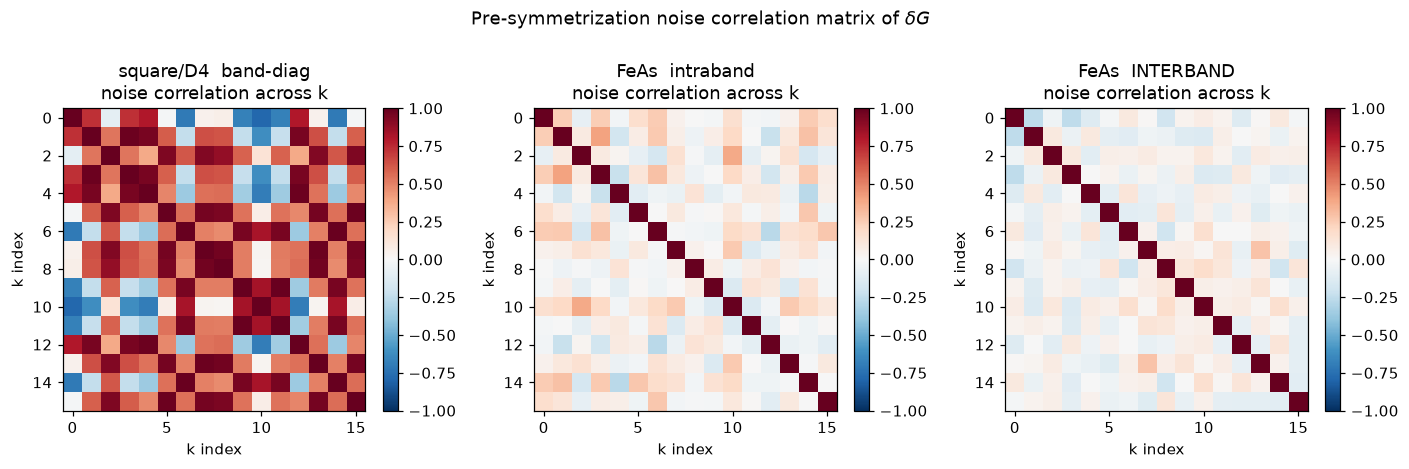

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))
for ax, (run, b0, b1, cls, label) in zip(axes, BLOCKS):
    C = nd.noise_corr_matrix(run, b0, b1)
    im = ax.imshow(C, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set(title=f'{label}\nnoise correlation across k', xlabel='k index', ylabel='k index')
    plt.colorbar(im, ax=ax, fraction=.046)
plt.suptitle('Pre-symmetrization noise correlation matrix of $\\delta G$', y=1.04)
plt.tight_layout()

## The source: the real-space noise profile `σ²(r)`

Fourier-transform the noise back to real space. Noise sitting at `r = 0` (the **local** component)
contributes identically to *every* momentum, since `e^{ik·0} = 1`. It is therefore perfectly
correlated across all `k` and completely immune to symmetrization.

A spatially **white** noise profile would put `1/N_k` in every cell (here `1/16 = 0.0625`). The
excess above that baseline is what drives `ρ`.

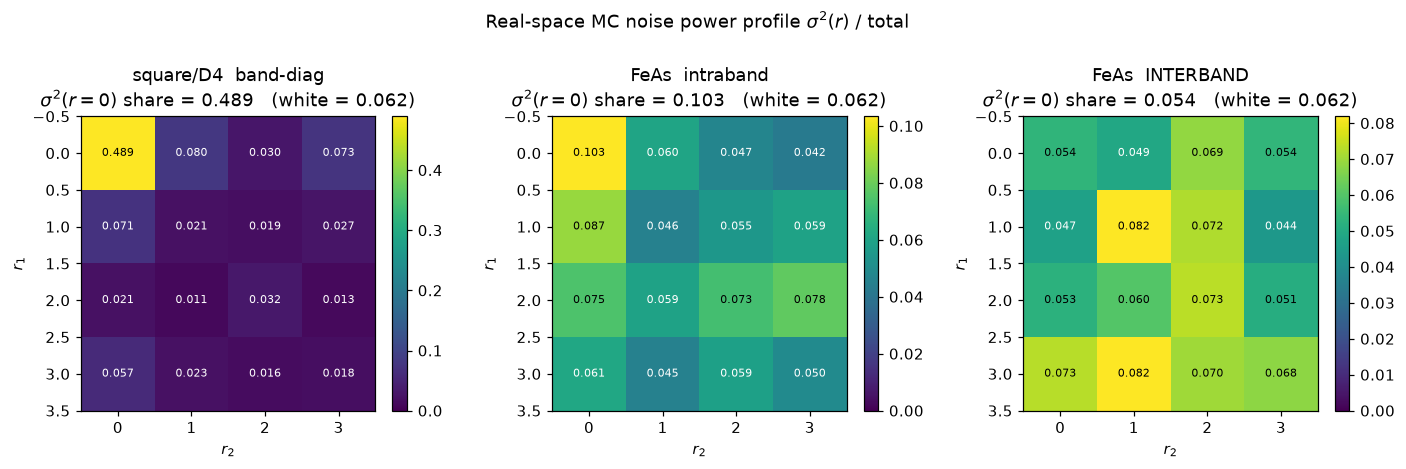

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))
for ax, (run, b0, b1, cls, label) in zip(axes, BLOCKS):
    prof = nd.realspace_noise_profile(run, b0, b1)
    im = ax.imshow(prof, cmap='viridis', vmin=0)
    for (i, j), v in np.ndenumerate(prof):
        ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                color='w' if v < prof.max()*.6 else 'k', fontsize=7)
    ax.set(title=f'{label}\n$\\sigma^2(r=0)$ share = {prof[0,0]:.3f}   (white = {1/run.nk:.3f})',
           xlabel='$r_2$', ylabel='$r_1$')
    plt.colorbar(im, ax=ax, fraction=.046)
plt.suptitle('Real-space MC noise power profile $\\sigma^2(r)$ / total', y=1.04)
plt.tight_layout()

### A quantitative predictor

Model the profile as a uniform background plus a local spike at `r=0`. Then for `q ≠ 0` the
normalized Fourier transform gives

$$\rho \;\approx\; \frac{\sigma^2(r=0)}{\text{total}} \;-\; \frac{1}{N_k}.$$

In [5]:
print(f"{'block':26s} {'predicted rho':>14s} {'measured rho':>14s}")
for run, b0, b1, cls, label in BLOCKS:
    print(f"{label:26s} {nd.predicted_rho(run, b0, b1):>14.4f} "
          f"{nd.pairwise_rho_all_k(run, b0, b1):>14.4f}")

block                       predicted rho   measured rho
square/D4  band-diag               0.4270         0.3977
FeAs  intraband                    0.0409         0.0414
FeAs  INTERBAND                   -0.0089        -0.0030


## The clincher: correlation between symmetry-equivalent *sites*

The most direct statement of the mechanism. Partition the real-space cluster into D4 shells and ask
whether `δM(r)` and `δM(S·r)` — the noise at symmetry-**equivalent sites** — already fluctuate
together. Symmetrization averages exactly those sites, so if they are already correlated, there is
nothing left to remove.

Note that square's *across*-shell correlation is **negative**, confirming this is specifically a
symmetry-aligned effect rather than generic common-mode noise.

square/D4  band-diag       within-shell +0.9054   across-shell -0.1833   shell sizes [1, 4, 2, 4, 4, 1]
FeAs  intraband            within-shell +0.0735   across-shell +0.0742   shell sizes [1, 4, 2, 4, 4, 1]
FeAs  INTERBAND            within-shell +0.1016   across-shell +0.1482   shell sizes [1, 4, 2, 4, 4, 1]


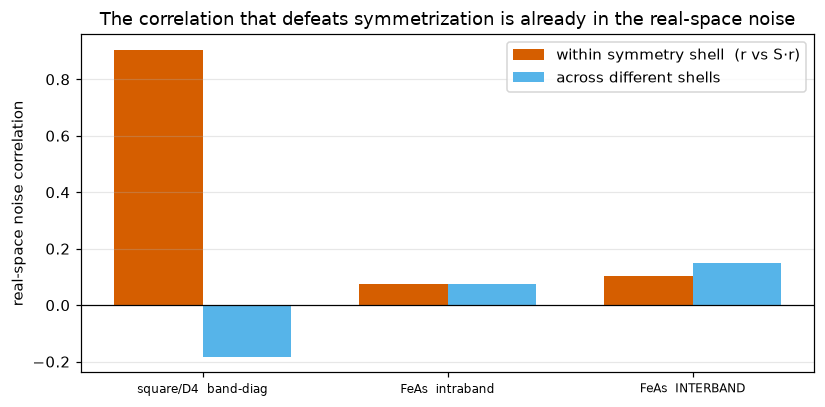

In [6]:
labels, wi, ac = [], [], []
for run, b0, b1, cls, label in BLOCKS:
    s = nd.shell_correlations(run, b0, b1)
    labels.append(label); wi.append(s['within']); ac.append(s['across'])
    print(f"{label:26s} within-shell {s['within']:+.4f}   across-shell {s['across']:+.4f}   "
          f"shell sizes {s['shell_sizes']}")

x = np.arange(len(labels)); w = 0.36
fig, ax = plt.subplots(figsize=(7.6, 3.8))
ax.bar(x - w/2, wi, w, label='within symmetry shell  (r vs S·r)', color='#D55E00')
ax.bar(x + w/2, ac, w, label='across different shells', color='#56B4E9')
ax.axhline(0, color='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set(ylabel='real-space noise correlation',
       title='The correlation that defeats symmetrization is already in the real-space noise')
ax.legend(); ax.grid(alpha=.3, axis='y'); plt.tight_layout()

## What this predicts

**Physical reading.** Noise dominated by fluctuations in globally **symmetric scalars** — expansion
order, average sign, density — is *entirely* symmetric, so `P` cannot touch it. Square at `β=1` is
exactly that regime: very high temperature, near-local physics, ~49% of all noise power in the single
local component. FeAs, with two bands and richer structure, has essentially white interband noise.

**Consequences:**

- **square/D4 at β=1 is ρ-limited** (`1/ρ ≈ 1.1`). Going to an 8×8 cluster would raise `m` from 4 to 8
  and buy almost nothing — the correlation ceiling binds first. To help square you must change the
  *noise structure*, which is what the β ladder tests: at lower temperature, correlations extend, the
  noise should acquire symmetry-breaking structure, `ρ` should fall and `R` should rise.
- **FeAs is m-limited** (`1/ρ ≈ 20`). Here bigger clusters, larger point groups, and band-permuting
  operations pay off almost directly.

**Where to expect maximum `R`:** multi-band models with band-permuting symmetry, on large clusters
with large point groups (2D `D4`=8, `D6`=12; 3D `O_h`=48), in entries where the noise is not
local-dominated. Since `R` is variance-weighted, the noisiest entries dominate it — and in square
those are precisely the local-dominated, high-`ρ` ones, which is why `R` lands at 1.04.

> **Note on numbers.** Like notebook 01, this one reads the committed 16-rank runs, so every `ρ` and
> `r` here is a single 16-rank draw. The mechanism they demonstrate is robust — the ordering,
> the mate-vs-generic gap and the shell structure all reproduce at 64 ranks — but for quotable
> values use the seed ensemble (`runs/seed_ensemble_*.json`): square `R = 1.0425 ± 0.0013`,
> FeAs `3.042 ± 0.049`.